# Weighted KNN

## Сегодня на практическом занятии:

1. Поработаем с 4 разными задачами (2 для классификации и 1 для регрессии)
2. Обучим модель Weighted KNN (взвешенный KNN) из sklearn
3. Получим предсказания моделью Weighted KNN (взвешенный KNN) вручную
4. Напишем свой способ подсчета весов для  Weighted KNN (взвешенный KNN)

In [1]:
#@title Установка нужных версий библиотек
#@title Установка нужных версий библиотек
%pip install scikit-learn pandas matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


## KNN для классификации

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [2]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Возьмите только 0 и 3 признак (sepal length (cm) и petal width (cm))

In [4]:
# Ваш код здесь

X = X.iloc[:, [0, 3]]
X.head()

,sepal length (cm),petal width (cm)
0,5.1,0.2
1,4.9,0.2
2,4.7,0.2
3,4.6,0.2
4,5.0,0.2


### Визуализируйте ваши данные на графике

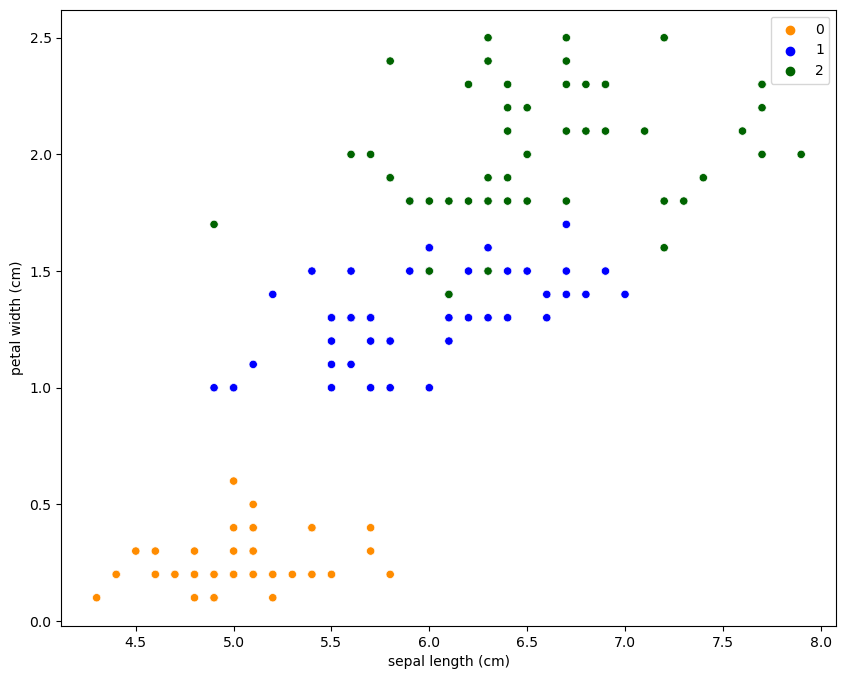

In [6]:
# Ваш код здесь

import seaborn as sns
import matplotlib.pyplot as plt
cmap_bold = ["darkorange", "blue", "darkgreen"]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X.iloc[:, 0],
    y=X.iloc[:, 1],
    hue=y,
    palette=cmap_bold
);

### 1. KNN из sklearn

#### 1.1. Разбейте данные на обучение и тест

In [7]:
# Ваш код здесь

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X.values, y, test_size=0.2, random_state=0)
X_train.shape, X_test.shape

((120, 2), (30, 2))

#### 1.2. Обучите модель KNN на 50 соседях

In [8]:
# Ваш код здесь

from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 50
model = KNeighborsClassifier(n_neighbors=n_neighbors)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50)

#### 1.3. Проверьте качество работы модели

По метрикам можете повторить эти занятия по [ссылке](https://youtube.com/playlist?list=PLkJJmZ1EJno6CLyvD4DHc32Fed6cPBHje)

T - True, P - possitive, N - negative
$$Accuracy = \frac{TP + TN}{P + N}$$

In [9]:
# Ваш код здесь

from sklearn.metrics import accuracy_score

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print(f'Train acc {accuracy_score(y_train, pred_train)}')
print(f'Test acc {accuracy_score(y_test, pred_test)}')

Train acc 0.8583333333333333
Test acc 0.8


#### 1.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
# Ваш код здесь

import numpy as np
import pandas as pd


def calculate_distances(test_dot: np.ndarray, X_train: np.ndarray, y_train: np.ndarray) -> pd.DataFrame:
    distance_list = []
    for i, train_dot in enumerate(X_train):  # 1
        distance_list.append({
            'train_idx': i,
            'dst': np.linalg.norm(train_dot - test_dot, ord=2),  # 2
            'y_train': y_train[i]
        })
    distances = pd.DataFrame(distance_list)
    return distances


idx = 7
test_dot = X_test[idx]
distances = calculate_distances(test_dot, X_train, y_train)
distances

,train_idx,dst,y_train
0,0,0.424264,2
1,1,1.300000,1
2,2,1.984943,0
3,3,0.670820,2
4,4,0.761577,2
...,...,...,...
115,115,2.280351,0
116,116,0.500000,2
117,117,1.029563,1
118,118,1.220656,2


#### 1.5. Выберите топ  k  соседей


In [15]:
# Ваш код здесь

distances = distances.sort_values('dst').head(n_neighbors)
nearest_neigbors_idxs = distances.index
distances

,train_idx,dst,y_train
87,87,0.100000,1
79,79,0.141421,1
103,103,0.200000,1
44,44,0.200000,1
109,109,0.223607,1
19,19,0.300000,2
28,28,0.316228,1
82,82,0.360555,1
16,16,0.360555,2
25,25,0.400000,2


#### 1.6. Выведите финальное предсказание для этого объекта

In [16]:
# Ваш код здесь

distances['y_train'].value_counts().index[0]

2

#### 1.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [17]:
# Ваш код здесь
y_test[idx]

1

In [18]:
# Ваш код здесь

model.predict(test_dot.reshape(1, -1))

array([2])

Предсказания полученное вручную и через модель не совпадает с истиной, можно попробовать обучить взвешенный KNN

#### 1.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

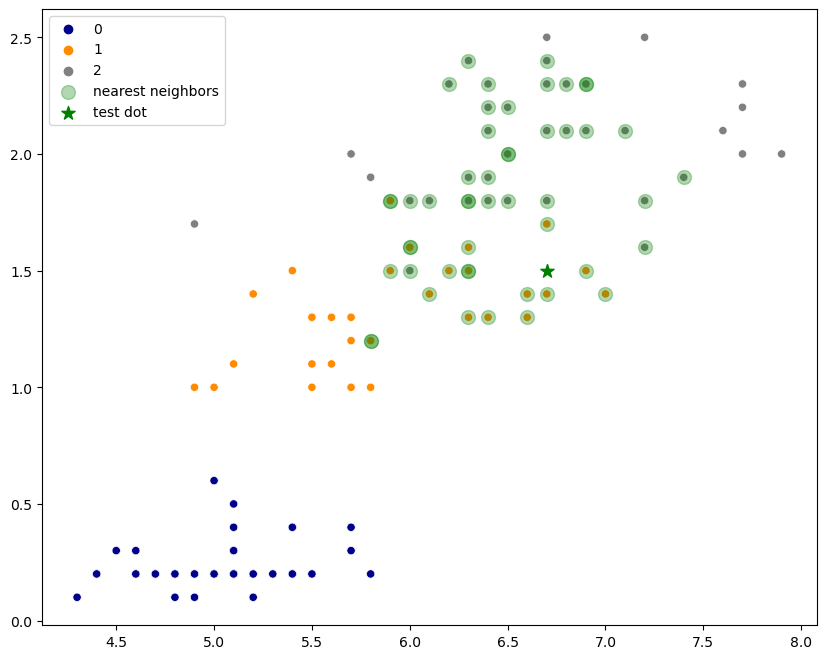

In [19]:
# Ваш код здесь

cmap_bold = ["darkblue", "darkorange", "gray"]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_train[:, 0],
    y=X_train[:, 1],
    hue=y_train,
    palette=cmap_bold
)

plt.scatter(X_train[nearest_neigbors_idxs, 0], X_train[nearest_neigbors_idxs, 1],
            c='g', alpha=0.3, marker='o', s=100, label='nearest neighbors')

plt.scatter(X_test[idx, 0], X_test[idx, 1], c='g', marker='*', s=100, label='test dot')
plt.legend();

### 2. Weighted KNN

#### 2.1. Обучите модель взвешенный KNN по дистанции

In [20]:
# Ваш код здесь

n_neighbors = 50
model = KNeighborsClassifier(n_neighbors=n_neighbors, weights='distance')
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50, weights='distance')

#### 2.2. Проверьте качество работы модели


In [21]:
# Ваш код здесь

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print(f'Train acc {accuracy_score(y_train, pred_train)}')
print(f'Test acc {accuracy_score(y_test, pred_test)}')

Train acc 0.9833333333333333
Test acc 0.9333333333333333


#### 2.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
# Ваш код здесь

test_dot = X_test[idx]
distances = calculate_distances(test_dot, X_train, y_train)
distances

,train_idx,dst,y_train
0,0,0.424264,2
1,1,1.300000,1
2,2,1.984943,0
3,3,0.670820,2
4,4,0.761577,2
...,...,...,...
115,115,2.280351,0
116,116,0.500000,2
117,117,1.029563,1
118,118,1.220656,2


#### 2.4. Выберите топ  k  соседей


In [23]:
# Ваш код здесь

distances = distances.sort_values('dst').head(n_neighbors)
nearest_neigbors_idxs = distances.index
distances

,train_idx,dst,y_train
87,87,0.100000,1
79,79,0.141421,1
103,103,0.200000,1
44,44,0.200000,1
109,109,0.223607,1
19,19,0.300000,2
28,28,0.316228,1
82,82,0.360555,1
16,16,0.360555,2
25,25,0.400000,2


#### 2.5. Рассчитайте вес для каждого соседа

In [24]:
# Ваш код здесь

distances['weight'] = 1 / (distances['dst'] + 1e-4)
distances

,train_idx,dst,y_train,weight
87,87,0.100000,1,9.990010
79,79,0.141421,1,7.066071
103,103,0.200000,1,4.997501
44,44,0.200000,1,4.997501
109,109,0.223607,1,4.470137
19,19,0.300000,2,3.332223
28,28,0.316228,1,3.161278
82,82,0.360555,1,2.772732
16,16,0.360555,2,2.772732
25,25,0.400000,2,2.499375


#### 2.6. Выведите финальное предсказание для этого объекта

In [25]:
# Ваш код здесь

display(f"Вес для класса 0 - {distances[distances['y_train'] == 0]['weight'].sum()}",
        f"Вес для класса 1 - {distances[distances['y_train'] == 1]['weight'].sum()}",
        f"Вес для класса 2 - {distances[distances['y_train'] == 2]['weight'].sum()}")

'Вес для класса 0 - 0.0'

'Вес для класса 1 - 55.61437011351792'

'Вес для класса 2 - 52.48379922441791'

#### 2.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [26]:
# Ваш код здесь
y_test[idx]

1

In [27]:
# Ваш код здесь

model.predict(test_dot.reshape(1, -1))

array([1])

Предсказания полученное вручную и через модель наконец-то совпадает с истиной, взвешенный KNN наам помог получить более качественную метрику.

#### 2.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

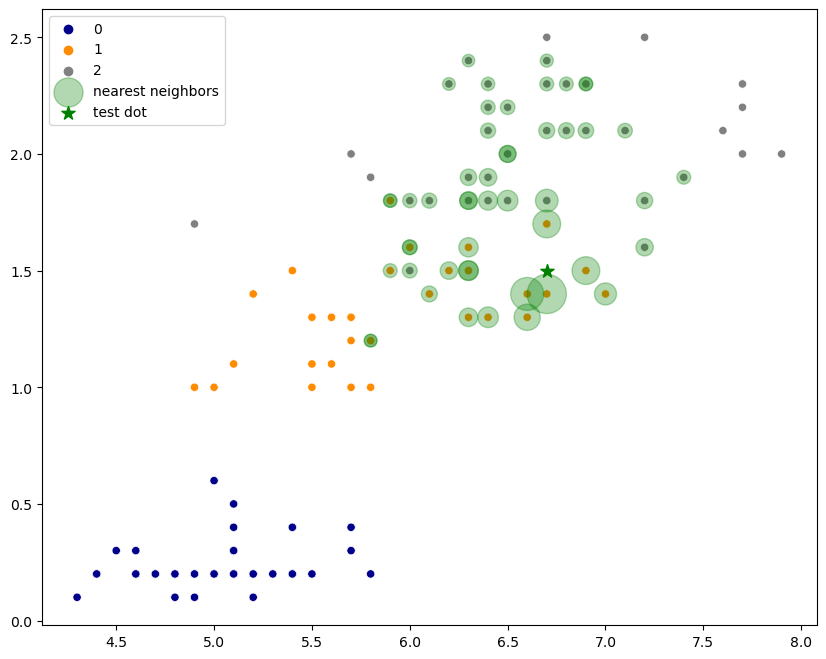

In [28]:
# Ваш код здесь

cmap_bold = ["darkblue", "darkorange", "gray"]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_train[:, 0],
    y=X_train[:, 1],
    hue=y_train,
    palette=cmap_bold
)

plt.scatter(X_train[nearest_neigbors_idxs, 0], X_train[nearest_neigbors_idxs, 1],
            c='g', alpha=0.3, marker='o', s=distances['weight']*80, label='nearest neighbors')

plt.scatter(X_test[idx, 0], X_test[idx, 1], c='g', marker='*', s=100, label='test dot')
plt.legend();

## 3. Еще одна задача классификации

### Получение данных

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

In [29]:
from sklearn.datasets import fetch_olivetti_faces
import pandas as pd


data = fetch_olivetti_faces(shuffle=True, random_state=9)

X = pd.DataFrame(data['data'])
y = data['target']

X.head()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /Users/19428031/scikit_learn_data


,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,0.723140,0.710744,0.714876,0.731405,0.735537,0.752066,0.772727,0.793388,0.814050,0.834711,...,0.793388,0.904959,0.549587,0.409091,0.491736,0.487603,0.471074,0.483471,0.475207,0.475207
1,0.289256,0.157025,0.148760,0.190083,0.169421,0.194215,0.404959,0.607438,0.669421,0.677686,...,0.438017,0.400826,0.421488,0.429752,0.433884,0.425620,0.438017,0.438017,0.210744,0.206612
2,0.586777,0.595041,0.681818,0.694215,0.714876,0.698347,0.714876,0.727273,0.743802,0.739669,...,0.495868,0.380165,0.400826,0.330579,0.148760,0.119835,0.123967,0.115702,0.119835,0.107438
3,0.235537,0.351240,0.479339,0.545455,0.566116,0.566116,0.595041,0.607438,0.619835,0.623967,...,0.169421,0.198347,0.202479,0.214876,0.202479,0.214876,0.214876,0.214876,0.210744,0.206612
4,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893


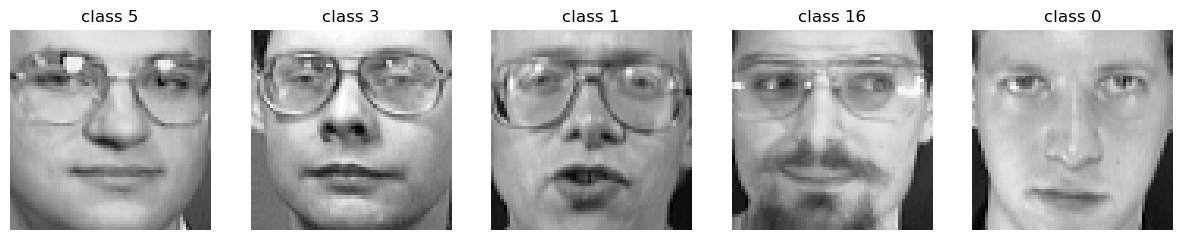

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 5, figsize=(15, 8))

for i in range(0, 5):
    ax[i].imshow(X.iloc[i].values.reshape((64, 64)), cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'class {y[i]}')

plt.show()

In [31]:
y

array([ 5,  3,  1, 16,  0,  1, 12,  9, 26, 37, 20,  5, 10, 27, 10, 34, 13,
       26, 17, 31,  9,  7, 31, 37, 31, 35, 18, 29, 29,  4, 21, 20, 23,  7,
        9, 18, 22,  2,  1, 39, 36,  8, 34, 32,  3, 20,  3,  9, 37, 32, 34,
       15,  9, 16, 36, 16, 13,  7, 29,  6, 13,  4, 16,  0,  8,  1, 25,  3,
       18, 29,  8, 35,  2, 25, 21, 31, 35, 23, 30, 28,  4, 10, 11, 27, 29,
       39,  5, 12, 29, 26, 15,  2, 39,  6, 30, 37, 25, 32, 35, 24, 15, 24,
        2, 19, 22,  0, 38,  5, 22, 28,  6, 38,  6,  3, 33, 12, 36,  8, 27,
       19, 25, 36, 10, 37,  9, 33, 10, 28, 32, 34, 17, 23, 19, 24, 27,  3,
       39, 30,  3,  7,  3, 30, 12, 21, 17, 14, 35, 21, 19,  5, 32, 16, 19,
        8, 33, 14, 17, 15, 22, 38, 15, 18,  7, 14, 28, 39, 23, 36, 28, 10,
       39, 36, 37, 10, 34, 25, 18, 13, 19, 33, 33, 13, 26,  9, 13, 34, 24,
        0, 30, 23,  2, 22,  9, 11,  7, 35, 19, 26, 32, 11,  7,  7,  0,  4,
        0,  2,  0, 26, 21, 14,  4, 32,  1, 23, 16,  0,  7, 14, 16, 15, 39,
       17, 33, 30, 37, 17

### 3.1. KNN из sklearn

#### 3.1.1. Разбейте данные на обучение и тест

In [32]:
# Ваш код здесь

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
X_train.shape, X_test.shape

((320, 4096), (80, 4096))

#### 3.1.2. Обучите модель KNN на 50 соседях

In [33]:
# Ваш код здесь

model = KNeighborsClassifier(n_neighbors=50)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50)

#### 3.1.3. Проверьте качество работы модели


In [34]:
# Ваш код здесь

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print(f'Train acc {accuracy_score(y_train, pred_train)}')
print(f'Test acc {accuracy_score(y_test, pred_test)}')

Train acc 0.434375
Test acc 0.3


### 3.2. Weighted KNN

#### 3.2.1. Обучите модель взвешенный KNN по дистанции

In [35]:
# Ваш код здесь

model = KNeighborsClassifier(n_neighbors=n_neighbors, weights='distance')
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50, weights='distance')

#### 3.2.2. Проверьте качество работы модели


In [36]:
# Ваш код здесь

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print(f'Train acc {accuracy_score(y_train, pred_train)}')
print(f'Test acc {accuracy_score(y_test, pred_test)}')

Train acc 1.0
Test acc 0.525


### 3.3. Custom Weighted KNN

#### 3.3.1. Напишите свою функцию подсчета весов по дистанции

(Можете выбрать любой подход)

In [37]:
# Ваш код здесь

def custom_distance(dists):
    return 0.5 ** dists

#### 3.3.2. Обучите модель взвешенный KNN по написанной функции выше

In [38]:
# Ваш код здесь

model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=custom_distance)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50,
                     weights=<function custom_distance at 0x150cfeac0>)

#### 3.3.3. Проверьте качество работы модели


In [39]:
# Ваш код здесь

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print(f'Train acc {accuracy_score(y_train, pred_train)}')
print(f'Test acc {accuracy_score(y_test, pred_test)}')

Train acc 1.0
Test acc 0.925


## KNN для регрессии

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [40]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [41]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

### Возьмите только признак MedInc и 1000 первых строк

In [42]:
# Ваш код здесь

X = X[['MedInc']]

In [43]:
X = X[:1000]
y = y[:1000]

### Отрисуйте данные на графике

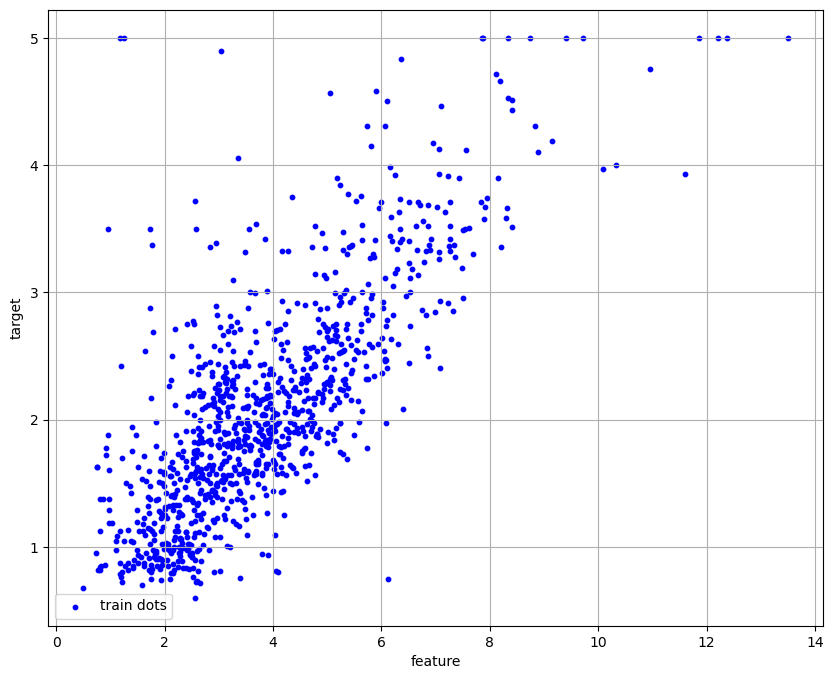

In [44]:
# Ваш код здесь

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(X, y, c='b', marker='o', s=10, label='train dots')

plt.grid()
plt.ylabel('target')
plt.xlabel('feature')
plt.legend();

### 4. KNN из sklearn

#### 4.1. Разбейте данные на обучение и тест

In [45]:
# Ваш код здесь

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X.values, y, test_size=0.2, random_state=4)
X_train.shape, X_test.shape

((800, 1), (200, 1))

#### 4.2. Обучите модель KNN на 100 соседях


In [46]:
# Ваш код здесь

from sklearn.neighbors import KNeighborsRegressor

n_neighbors = 100
model = KNeighborsRegressor(n_neighbors=n_neighbors)
model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100)

#### 4.3. Проверьте качество работы модели

Доп информация по метрикам [здесь](https://youtu.be/vh2smjQyhp8)

In [47]:
# Ваш код здесь

from sklearn.metrics import r2_score

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print(f'Train r2 {r2_score(y_train, pred_train)}')
print(f'Test r2 {r2_score(y_test, pred_test)}')

Train r2 0.5831842264199859
Test r2 0.5506986719860942


#### 4.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
# Ваш код здесь

idx = 7
test_dot = X_test[idx]
distances = calculate_distances(test_dot, X_train, y_train)
distances

,train_idx,dst,y_train
0,0,6.7573,1.90800
1,1,4.3459,5.00001
2,2,4.1531,2.64700
3,3,6.1298,2.55000
4,4,3.8930,2.92700
...,...,...,...
795,795,4.1916,2.28000
796,796,5.9735,1.70300
797,797,6.5849,1.20000
798,798,6.8834,1.27000


#### 4.5. Выберите топ  k  соседей


In [50]:
# Ваш код здесь

distances = distances.sort_values('dst').head(n_neighbors)
nearest_neigbors_idxs = distances.index
distances

,train_idx,dst,y_train
577,577,0.2428,5.00001
536,536,0.3189,4.30500
152,152,0.7521,3.51200
257,257,0.7535,4.42900
247,247,0.8194,5.00001
...,...,...,...
622,622,3.3149,3.30200
574,574,3.3206,2.98900
477,477,3.3209,2.81800
537,537,3.3361,2.57300


#### 4.6. Выведите финальное предсказание для этого объекта

In [51]:
# Ваш код здесь

distances['y_train'].mean()

3.4591405999999996

#### 4.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [52]:
# Ваш код здесь
y_test[idx]

4.188

In [53]:
# Ваш код здесь

model.predict(test_dot.reshape(1, -1))

array([3.4591406])

Предсказания полученное вручную и через модель не совпадает с истиной, можно попробовать обучить взвешенный KNN

#### 4.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

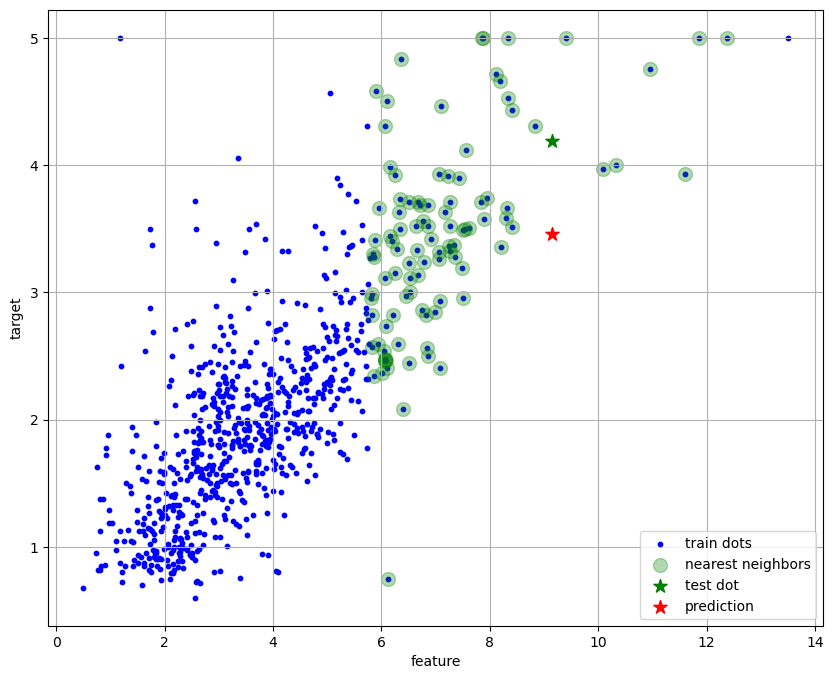

In [54]:
# Ваш код здесь

plt.figure(figsize=(10, 8))

plt.scatter(X_train, y_train, c='b', marker='o', s=10, label='train dots')
plt.grid()

plt.scatter(X_train[nearest_neigbors_idxs], y_train[nearest_neigbors_idxs],
            c='g', alpha=0.3, marker='o', s=100, label='nearest neighbors')

plt.scatter(X_test[idx, 0], y_test[idx], c='g', marker='*', s=100, label='test dot')
plt.scatter(X_test[idx, 0], pred_test[idx], c='r', marker='*', s=100, label='prediction')

plt.xlabel('feature')
plt.ylabel('target')

plt.legend();

In [55]:
prev_pred_test = pred_test.copy()

### 5. Weighted KNN

#### 5.1. Обучите модель взвешенный KNN по дистанции

In [56]:
# Ваш код здесь

model = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')
model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100, weights='distance')

#### 5.2. Проверьте качество работы модели


In [57]:
# Ваш код здесь

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print(f'Train r2 {r2_score(y_train, pred_train)}')
print(f'Test r2 {r2_score(y_test, pred_test)}')

Train r2 0.9829084668940636
Test r2 0.5198213764632077


#### 5.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
# Ваш код здесь

test_dot = X_test[idx]
distances = calculate_distances(test_dot, X_train, y_train)
distances

,train_idx,dst,y_train
0,0,6.7573,1.90800
1,1,4.3459,5.00001
2,2,4.1531,2.64700
3,3,6.1298,2.55000
4,4,3.8930,2.92700
...,...,...,...
795,795,4.1916,2.28000
796,796,5.9735,1.70300
797,797,6.5849,1.20000
798,798,6.8834,1.27000


#### 5.4. Выберите топ  k  соседей


In [59]:
# Ваш код здесь

distances = distances.sort_values('dst').head(n_neighbors)
nearest_neigbors_idxs = distances.index
distances

,train_idx,dst,y_train
577,577,0.2428,5.00001
536,536,0.3189,4.30500
152,152,0.7521,3.51200
257,257,0.7535,4.42900
247,247,0.8194,5.00001
...,...,...,...
622,622,3.3149,3.30200
574,574,3.3206,2.98900
477,477,3.3209,2.81800
537,537,3.3361,2.57300


#### 5.5. Рассчитайте вес для каждого соседа

In [60]:
# Ваш код здесь

distances['weight'] = 1 / (distances['dst'] + 1e-4)
distances

,train_idx,dst,y_train,weight
577,577,0.2428,5.00001,4.116921
536,536,0.3189,4.30500,3.134796
152,152,0.7521,3.51200,1.329434
257,257,0.7535,4.42900,1.326964
247,247,0.8194,5.00001,1.220256
...,...,...,...,...
622,622,3.3149,3.30200,0.301659
574,574,3.3206,2.98900,0.301141
477,477,3.3209,2.81800,0.301114
537,537,3.3361,2.57300,0.299742


#### 5.6. Выведите финальное предсказание для этого объекта

In [61]:
# Ваш код здесь

(distances['y_train'] * distances['weight']).sum() / distances['weight'].sum()

3.737367744758446

#### 5.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [62]:
# Ваш код здесь
y_test[idx]

4.188

In [63]:
# Ваш код здесь

model.predict(test_dot.reshape(1, -1))

array([3.73741778])

Предсказания полученное вручную и через модель стали ближе к истине, чем были до взвешенного KNN.

#### 5.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

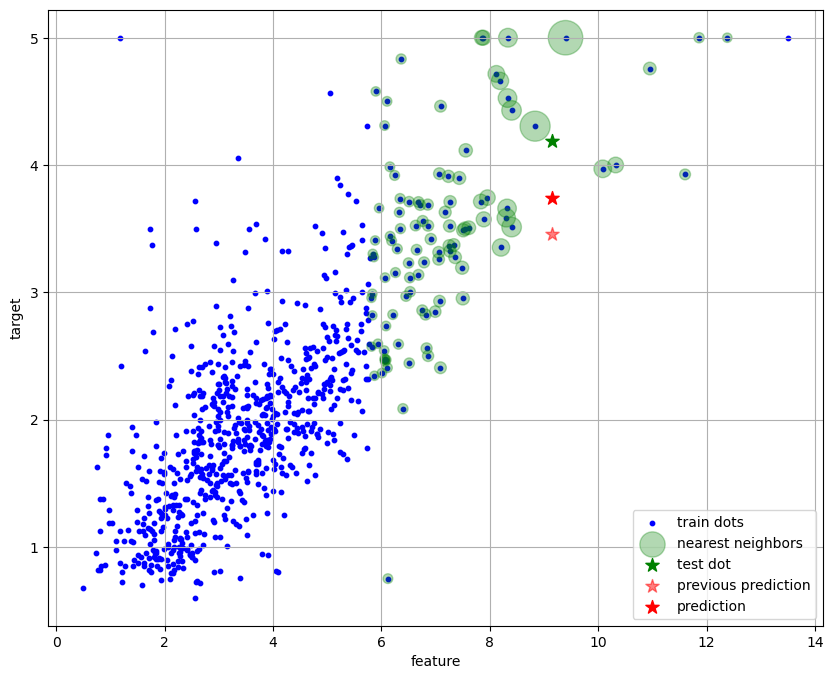

In [64]:
# Ваш код здесь

plt.figure(figsize=(10, 8))

plt.scatter(X_train, y_train, c='b', marker='o', s=10, label='train dots')
plt.grid()

plt.scatter(X_train[nearest_neigbors_idxs], y_train[nearest_neigbors_idxs],
            c='g', alpha=0.3, marker='o', s=distances['weight']*150, label='nearest neighbors')

plt.scatter(X_test[idx, 0], y_test[idx], c='g', marker='*', s=100, label='test dot')
plt.scatter(X_test[idx, 0], prev_pred_test[idx], c='r', alpha=0.5, marker='*', s=100, label='previous prediction')
plt.scatter(X_test[idx, 0], pred_test[idx], c='r', marker='*', s=100, label='prediction')

plt.xlabel('feature')
plt.ylabel('target')

plt.legend();

## Резюме

Сегодня на практическом занятии:
1. Поработали с 4 разными задачами (2 для классификации и 1 для регрессии)
2. Обучили модель Weighted KNN (взвешенный KNN) из sklearn
3. Получили предсказания моделью Weighted KNN (взвешенный KNN) вручную
4. Написали свой способ подсчета весов для  Weighted KNN (взвешенный KNN)